In [24]:
# =======================================================================
#                    PROJECT MACHINE LEARNING
#            Prediksi Kelayakan Pinjaman Nasabah Bank
# =======================================================================

# ============================================
# IMPORT LIBRARY
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

from imblearn.over_sampling import SMOTE

# Setting style grafik biar cantik
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("✓ Semua library berhasil diimport")
print("✓ Style grafik sudah diatur")

✓ Semua library berhasil diimport
✓ Style grafik sudah diatur


In [25]:
# ============================================
# MOUNT GOOGLE DRIVE
# ============================================

from google.colab import drive
drive.mount('/content/drive')

print("✓ Google Drive berhasil di-mount")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Google Drive berhasil di-mount


In [26]:
# ============================================
# LOAD DATASET
# ============================================

import io

# Sesuaikan path dengan lokasi file Anda
file_path = '/content/drive/MyDrive/Colab Notebooks/arina/loan_data.csv'

with open(file_path) as f:
    content = f.read()

df = pd.read_csv(io.StringIO(content), sep=';')

print("="*50)
print("5 DATA PERTAMA")
print("="*50)
display(df.head())

print("\n" + "="*50)
print("INFO DATASET")
print("="*50)
print(df.info())

print("\n" + "="*50)
print("UKURAN DATASET")
print("="*50)
print(f"Jumlah baris: {df.shape[0]}")
print(f"Jumlah kolom: {df.shape[1]}")

5 DATA PERTAMA


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y



INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            381 non-null    object 
 1   Gender             376 non-null    object 
 2   Married            381 non-null    object 
 3   Dependents         373 non-null    object 
 4   Education          381 non-null    object 
 5   Self_Employed      360 non-null    object 
 6   ApplicantIncome    381 non-null    int64  
 7   CoapplicantIncome  381 non-null    object 
 8   LoanAmount         381 non-null    float64
 9   Loan_Amount_Term   370 non-null    float64
 10  Credit_History     351 non-null    float64
 11  Property_Area      381 non-null    object 
 12  Loan_Status        381 non-null    object 
dtypes: float64(3), int64(1), object(9)
memory usage: 38.8+ KB
None

UKURAN DATASET
Jumlah baris: 381
Jumlah kolom: 13


CEK MISSING VALUE
Jumlah missing value per kolom:
Loan_ID               0
Gender                5
Married               0
Dependents            8
Education             0
Self_Employed        21
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     11
Credit_History       30
Property_Area         0
Loan_Status           0
dtype: int64

Total missing value: 75


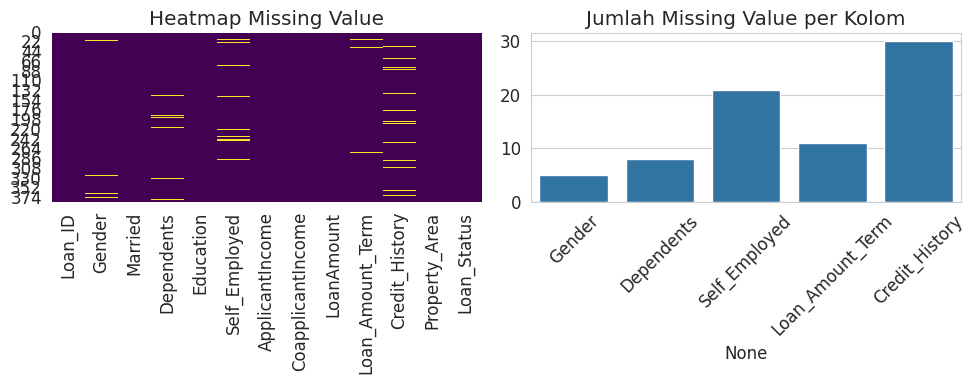

In [27]:
# ============================================
# CEK MISSING VALUE
# ============================================

print("="*50)
print("CEK MISSING VALUE")
print("="*50)

print("Jumlah missing value per kolom:")
print(df.isnull().sum())

print(f"\nTotal missing value: {df.isnull().sum().sum()}")

# Visualisasi missing value
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Heatmap Missing Value")

plt.subplot(1,2,2)
missing_count = df.isnull().sum()
missing_count = missing_count[missing_count > 0]
if len(missing_count) > 0:
    sns.barplot(x=missing_count.index, y=missing_count.values)
    plt.title("Jumlah Missing Value per Kolom")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

HANDLING MISSING VALUE
Kolom numerik: ['ApplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
Kolom kategorikal: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'CoapplicantIncome', 'Property_Area', 'Loan_Status']

----------------------------------------
PENJELASAN: Mengapa menggunakan MEDIAN untuk data numerik?
----------------------------------------

1. Median adalah nilai tengah dari data yang telah diurutkan
2. Median lebih tahan (robust) terhadap OUTLIER dibandingkan Mean
3. Contoh: Data pendapatan [5jt, 6jt, 7jt, 8jt, 1M]
   - Mean = Rp 205.200.000 (tidak mewakili)
   - Median = Rp 7.000.000 (mewakili data sebenarnya)


PROSES HANDLING NUMERIK (MEDIAN):
  ✓ Loan_Amount_Term: missing 11 → 0 (diisi median = 360.0)
  ✓ Credit_History: missing 30 → 0 (diisi median = 1.0)

----------------------------------------
PENJELASAN: Mengapa menggunakan MODUS untuk data kategorikal?
----------------------------------------

1. Modus adalah nilai y

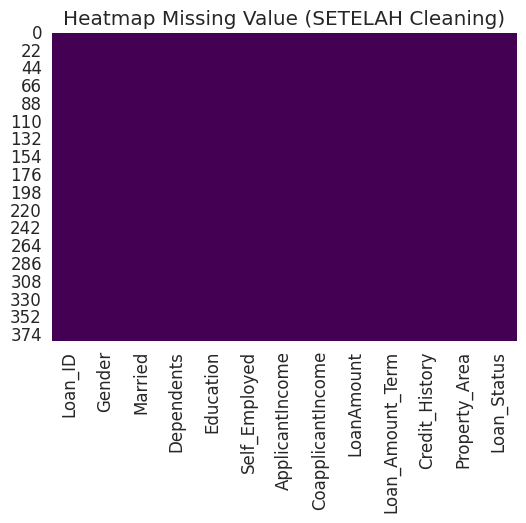

In [28]:
# ============================================
# HANDLING MISSING VALUE
# ============================================

print("="*50)
print("HANDLING MISSING VALUE")
print("="*50)

# Identifikasi kolom numerik dan kategorikal
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print(f"Kolom numerik: {list(num_cols)}")
print(f"Kolom kategorikal: {list(cat_cols)}")

# ============================================
# PENJELASAN ALASAN MEDIAN UNTUK NUMERIK
# ============================================

print("\n" + "-"*40)
print("PENJELASAN: Mengapa menggunakan MEDIAN untuk data numerik?")
print("-"*40)
print("""
1. Median adalah nilai tengah dari data yang telah diurutkan
2. Median lebih tahan (robust) terhadap OUTLIER dibandingkan Mean
3. Contoh: Data pendapatan [5jt, 6jt, 7jt, 8jt, 1M]
   - Mean = Rp 205.200.000 (tidak mewakili)
   - Median = Rp 7.000.000 (mewakili data sebenarnya)
""")

# Handling numerik dengan MEDIAN
print("\nPROSES HANDLING NUMERIK (MEDIAN):")
for col in num_cols:
    if df[col].isnull().sum() > 0:
        sebelum = df[col].isnull().sum()
        nilai_median = df[col].median()
        df[col] = df[col].fillna(nilai_median)
        sesudah = df[col].isnull().sum()
        print(f"  ✓ {col}: missing {sebelum} → {sesudah} (diisi median = {nilai_median})")

# ============================================
# PENJELASAN ALASAN MODUS UNTUK KATEGORIKAL
# ============================================

print("\n" + "-"*40)
print("PENJELASAN: Mengapa menggunakan MODUS untuk data kategorikal?")
print("-"*40)
print("""
1. Modus adalah nilai yang PALING SERING MUNCUL dalam suatu kolom
2. Untuk data kategorikal, tidak masuk akal menggunakan mean/median
3. Contoh: Data gender [Laki, Laki, Laki, Perempuan, Perempuan]
   - Modus = Laki-laki (paling representatif)
""")

# Handling kategorikal dengan MODUS
print("\nPROSES HANDLING KATEGORIKAL (MODUS):")
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        sebelum = df[col].isnull().sum()
        nilai_modus = df[col].mode()[0]
        df[col] = df[col].fillna(nilai_modus)
        sesudah = df[col].isnull().sum()
        print(f"  ✓ {col}: missing {sebelum} → {sesudah} (diisi modus = '{nilai_modus}')")

print("\n" + "-"*40)
print("HASIL AKHIR SETELAH HANDLING:")
print("-"*40)
print(f"Total missing value setelah cleaning: {df.isnull().sum().sum()}")

# Visualisasi setelah handling
plt.figure(figsize=(6,4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Heatmap Missing Value (SETELAH Cleaning)")
plt.show()

In [29]:
# ============================================
# ENCODING DATA KATEGORIKAL (Label Encoding)
# ============================================

print("="*50)
print("LABEL ENCODING")
print("="*50)

# Identifikasi ulang kolom kategorikal
cat_cols = df.select_dtypes(include=['object']).columns
le = LabelEncoder()

print("Proses encoding teks → angka:")
for col in cat_cols:
    sebelum = df[col].unique()[:3]
    df[col] = le.fit_transform(df[col])
    sesudah = df[col].unique()[:3]
    print(f"  ✓ {col}: {sebelum} → {sesudah}")

print("\n" + "-"*40)
print("DATA SETELAH ENCODING:")
print("-"*40)
display(df.head())

print("\nInfo target Loan_Status:")
print(df['Loan_Status'].value_counts())

LABEL ENCODING
Proses encoding teks → angka:
  ✓ Loan_ID: ['LP001003' 'LP001005' 'LP001006'] → [0 1 2]
  ✓ Gender: ['Male' 'Female'] → [1 0]
  ✓ Married: ['Yes' 'No'] → [1 0]
  ✓ Dependents: ['1' '0' '2'] → [1 0 2]
  ✓ Education: ['Graduate' 'Not Graduate'] → [0 1]
  ✓ Self_Employed: ['No' 'Yes'] → [0 1]
  ✓ CoapplicantIncome: ['1508.0' '0.0' '2358.0'] → [ 31   0 110]
  ✓ Property_Area: ['Rural' 'Urban' 'Semiurban'] → [0 2 1]
  ✓ Loan_Status: ['N' 'Y'] → [0 1]

----------------------------------------
DATA SETELAH ENCODING:
----------------------------------------


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,1,1,0,0,4583,31,128.0,360.0,1.0,0,0
1,1,1,1,0,0,1,3000,0,66.0,360.0,1.0,2,1
2,2,1,1,0,1,0,2583,110,120.0,360.0,1.0,2,1
3,3,1,0,0,0,0,6000,0,141.0,360.0,1.0,2,1
4,4,1,1,0,1,0,2333,32,95.0,360.0,1.0,2,1



Info target Loan_Status:
Loan_Status
1    271
0    110
Name: count, dtype: int64


SMOTE (Synthetic Minority Over-sampling)

----------------------------------------
📊 KONDISI SEBELUM SMOTE:
----------------------------------------
Kelas 0 (Tidak Layak): 110 data (28.9%)
Kelas 1 (Layak)     : 271 data (71.1%)
Rasio (Layak : Tidak Layak) = 2.46 : 1


/tmp/ipykernel_1629/3958805715.py:70: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1629/3958805715.py:70: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


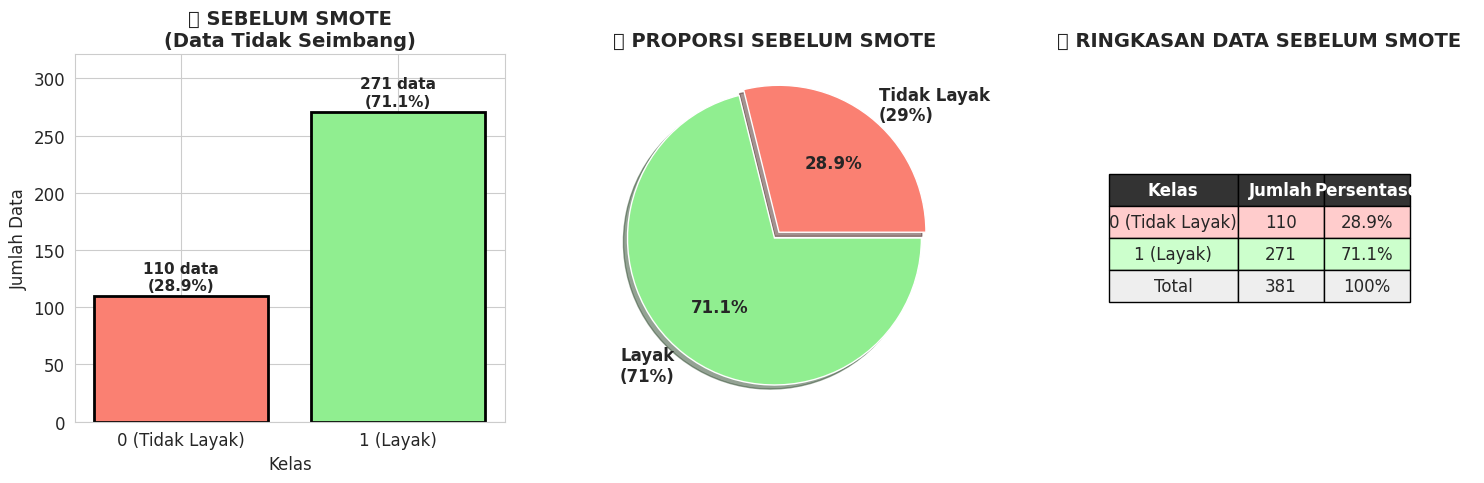


----------------------------------------
🔄 PROSES SMOTE:
----------------------------------------
SMOTE bekerja dengan cara:
  1. Memilih data kelas minoritas (Tidak Layak)
  2. Mencari tetangga terdekat dari data tersebut
  3. Membuat data SINTETIS (buatan) di antara tetangganya
  4. Menambahkan data baru sampai jumlahnya seimbang

----------------------------------------
📊 KONDISI SETELAH SMOTE:
----------------------------------------
Kelas 0 (Tidak Layak): 271 data (50.0%)
Kelas 1 (Layak)     : 271 data (50.0%)
Rasio (Layak : Tidak Layak) = 1.00 : 1


/tmp/ipykernel_1629/3958805715.py:150: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1629/3958805715.py:150: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


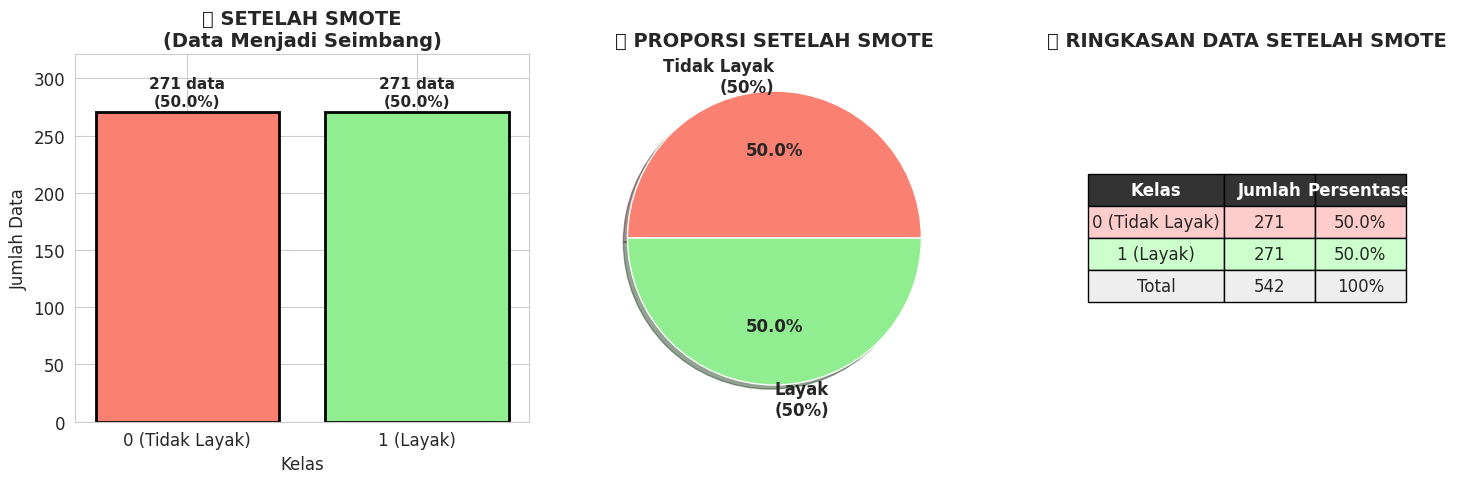


----------------------------------------
📊 PERBANDINGAN SEBELUM vs SETELAH SMOTE:
----------------------------------------


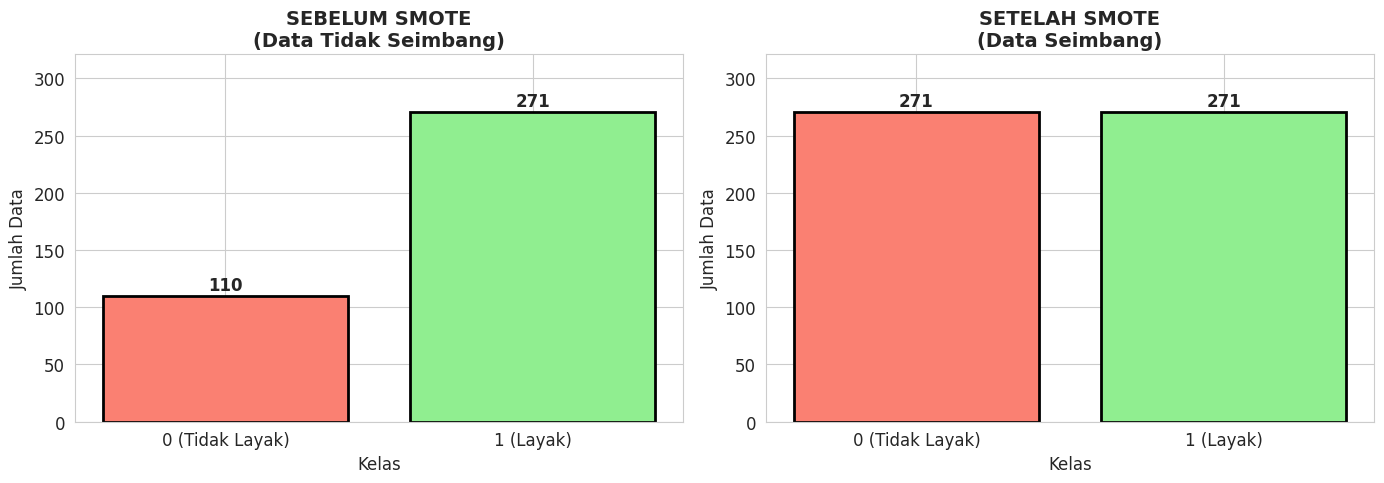


✅ SMOTE SELESAI!

📈 RINGKASAN PERUBAHAN:

   ┌─────────────────────┬──────────────────┬──────────────────┐
   │                     │   SEBELUM SMOTE   │  SETELAH SMOTE   │
   ├─────────────────────┼──────────────────┼──────────────────┤
   │ Kelas 0 (Tidak Layak)│     110 data (29%)      │     271 data (50%)       │
   ├─────────────────────┼──────────────────┼──────────────────┤
   │ Kelas 1 (Layak)     │     271 data (71%)      │     271 data (50%)       │
   ├─────────────────────┼──────────────────┼──────────────────┤
   │ Rasio (Layak:Tdk)   │     2.46 : 1      │       1.00 : 1      │
   ├─────────────────────┼──────────────────┼──────────────────┤
   │ Total Data          │       381 data      │     542 data     │
   └─────────────────────┴──────────────────┴──────────────────┘

💡 PENJELASAN:
   - SMOTE membuat 161 data SINTETIS (buatan) untuk kelas Tidak Layak
   - Sekarang jumlah kedua kelas SAMA (seimbang 50:50)
   - Model akan belajar lebih ADIL untuk kedua kelas

🎯 Data se

In [30]:


# ============================================
# SMOTE - MENGATASI DATA TIDAK SEIMBANG
# ============================================

print("="*60)
print("SMOTE (Synthetic Minority Over-sampling)")
print("="*60)

# Pisahkan X dan y DARI DATA ASLI (sebelum SMOTE)
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# ============================================
# GRAFIK SEBELUM SMOTE (Data Asli Tidak Seimbang)
# ============================================

print("\n" + "-"*40)
print("📊 KONDISI SEBELUM SMOTE:")
print("-"*40)

before_counts = y.value_counts().sort_index()
print(f"Kelas 0 (Tidak Layak): {before_counts[0]} data ({before_counts[0]/len(y)*100:.1f}%)")
print(f"Kelas 1 (Layak)     : {before_counts[1]} data ({before_counts[1]/len(y)*100:.1f}%)")
print(f"Rasio (Layak : Tidak Layak) = {before_counts[1]/before_counts[0]:.2f} : 1")

# GRAFIK 1: Barplot Sebelum SMOTE
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Barplot
axes[0].bar(['0 (Tidak Layak)', '1 (Layak)'], before_counts.values,
            color=['salmon', 'lightgreen'], edgecolor='black', linewidth=2)
axes[0].set_title('📊 SEBELUM SMOTE\n(Data Tidak Seimbang)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Kelas', fontsize=12)
axes[0].set_ylabel('Jumlah Data', fontsize=12)
axes[0].set_ylim(0, max(before_counts) + 50)
for i, v in enumerate(before_counts.values):
    axes[0].text(i, v + 5, f'{v} data\n({v/len(y)*100:.1f}%)', ha='center', fontweight='bold', fontsize=11)

# Pie chart sebelum
axes[1].pie(before_counts.values, labels=['Tidak Layak\n(29%)', 'Layak\n(71%)'],
            autopct='%1.1f%%', colors=['salmon', 'lightgreen'],
            explode=(0.05, 0), shadow=True, textprops={'fontsize': 12, 'weight': 'bold'})
axes[1].set_title('📊 PROPORSI SEBELUM SMOTE', fontsize=14, fontweight='bold')

# Tabel informasi sebelum
axes[2].axis('off')
table_data = [
    ['Kelas', 'Jumlah', 'Persentase'],
    ['0 (Tidak Layak)', f'{before_counts[0]}', f'{before_counts[0]/len(y)*100:.1f}%'],
    ['1 (Layak)', f'{before_counts[1]}', f'{before_counts[1]/len(y)*100:.1f}%'],
    ['Total', f'{len(y)}', '100%']
]
table = axes[2].table(cellText=table_data, loc='center', cellLoc='center', colWidths=[0.3, 0.2, 0.2])
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)
for i, row in enumerate(table_data):
    for j in range(3):
        if i == 0:
            table[(i, j)].set_facecolor('#333333')
            table[(i, j)].set_text_props(color='white', fontweight='bold')
        elif i == 1:
            table[(i, j)].set_facecolor('#ffcccc')
        elif i == 2:
            table[(i, j)].set_facecolor('#ccffcc')
        else:
            table[(i, j)].set_facecolor('#eeeeee')
axes[2].set_title('📋 RINGKASAN DATA SEBELUM SMOTE', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# TERAPKAN SMOTE
# ============================================

print("\n" + "-"*40)
print("🔄 PROSES SMOTE:")
print("-"*40)
print("SMOTE bekerja dengan cara:")
print("  1. Memilih data kelas minoritas (Tidak Layak)")
print("  2. Mencari tetangga terdekat dari data tersebut")
print("  3. Membuat data SINTETIS (buatan) di antara tetangganya")
print("  4. Menambahkan data baru sampai jumlahnya seimbang")

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Buat dataframe baru hasil SMOTE
df_balanced = pd.DataFrame(X_resampled, columns=X.columns)
df_balanced['Loan_Status'] = y_resampled

# ============================================
# GRAFIK SETELAH SMOTE (Data Seimbang)
# ============================================

print("\n" + "-"*40)
print("📊 KONDISI SETELAH SMOTE:")
print("-"*40)

after_counts = df_balanced['Loan_Status'].value_counts().sort_index()
print(f"Kelas 0 (Tidak Layak): {after_counts[0]} data ({after_counts[0]/len(df_balanced)*100:.1f}%)")
print(f"Kelas 1 (Layak)     : {after_counts[1]} data ({after_counts[1]/len(df_balanced)*100:.1f}%)")
print(f"Rasio (Layak : Tidak Layak) = {after_counts[1]/after_counts[0]:.2f} : 1")

# GRAFIK 2: Barplot Setelah SMOTE
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Barplot
axes[0].bar(['0 (Tidak Layak)', '1 (Layak)'], after_counts.values,
            color=['salmon', 'lightgreen'], edgecolor='black', linewidth=2)
axes[0].set_title('📊 SETELAH SMOTE\n(Data Menjadi Seimbang)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Kelas', fontsize=12)
axes[0].set_ylabel('Jumlah Data', fontsize=12)
axes[0].set_ylim(0, max(after_counts) + 50)
for i, v in enumerate(after_counts.values):
    axes[0].text(i, v + 5, f'{v} data\n({v/len(df_balanced)*100:.1f}%)', ha='center', fontweight='bold', fontsize=11)

# Pie chart setelah
axes[1].pie(after_counts.values, labels=['Tidak Layak\n(50%)', 'Layak\n(50%)'],
            autopct='%1.1f%%', colors=['salmon', 'lightgreen'],
            explode=(0, 0), shadow=True, textprops={'fontsize': 12, 'weight': 'bold'})
axes[1].set_title('📊 PROPORSI SETELAH SMOTE', fontsize=14, fontweight='bold')

# Tabel informasi setelah
axes[2].axis('off')
table_data = [
    ['Kelas', 'Jumlah', 'Persentase'],
    ['0 (Tidak Layak)', f'{after_counts[0]}', f'{after_counts[0]/len(df_balanced)*100:.1f}%'],
    ['1 (Layak)', f'{after_counts[1]}', f'{after_counts[1]/len(df_balanced)*100:.1f}%'],
    ['Total', f'{len(df_balanced)}', '100%']
]
table = axes[2].table(cellText=table_data, loc='center', cellLoc='center', colWidths=[0.3, 0.2, 0.2])
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)
for i, row in enumerate(table_data):
    for j in range(3):
        if i == 0:
            table[(i, j)].set_facecolor('#333333')
            table[(i, j)].set_text_props(color='white', fontweight='bold')
        elif i == 1:
            table[(i, j)].set_facecolor('#ffcccc')
        elif i == 2:
            table[(i, j)].set_facecolor('#ccffcc')
        else:
            table[(i, j)].set_facecolor('#eeeeee')
axes[2].set_title('📋 RINGKASAN DATA SETELAH SMOTE', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# GRAFIK PERBANDINGAN (SEBELUM vs SETELAH)
# ============================================

print("\n" + "-"*40)
print("📊 PERBANDINGAN SEBELUM vs SETELAH SMOTE:")
print("-"*40)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sebelum
axes[0].bar(['0 (Tidak Layak)', '1 (Layak)'], before_counts.values,
            color=['salmon', 'lightgreen'], edgecolor='black', linewidth=2)
axes[0].set_title('SEBELUM SMOTE\n(Data Tidak Seimbang)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Kelas', fontsize=12)
axes[0].set_ylabel('Jumlah Data', fontsize=12)
axes[0].set_ylim(0, max(before_counts.max(), after_counts.max()) + 50)
for i, v in enumerate(before_counts.values):
    axes[0].text(i, v + 5, f'{v}', ha='center', fontweight='bold', fontsize=12)

# Setelah
axes[1].bar(['0 (Tidak Layak)', '1 (Layak)'], after_counts.values,
            color=['salmon', 'lightgreen'], edgecolor='black', linewidth=2)
axes[1].set_title('SETELAH SMOTE\n(Data Seimbang)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Kelas', fontsize=12)
axes[1].set_ylabel('Jumlah Data', fontsize=12)
axes[1].set_ylim(0, max(before_counts.max(), after_counts.max()) + 50)
for i, v in enumerate(after_counts.values):
    axes[1].text(i, v + 5, f'{v}', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# ============================================
# KESIMPULAN SMOTE
# ============================================

print("\n" + "="*50)
print("✅ SMOTE SELESAI!")
print("="*50)

print(f"""
📈 RINGKASAN PERUBAHAN:

   ┌─────────────────────┬──────────────────┬──────────────────┐
   │                     │   SEBELUM SMOTE   │  SETELAH SMOTE   │
   ├─────────────────────┼──────────────────┼──────────────────┤
   │ Kelas 0 (Tidak Layak)│     {before_counts[0]:3d} data ({before_counts[0]/len(y)*100:.0f}%)      │     {after_counts[0]:3d} data ({after_counts[0]/len(df_balanced)*100:.0f}%)       │
   ├─────────────────────┼──────────────────┼──────────────────┤
   │ Kelas 1 (Layak)     │     {before_counts[1]:3d} data ({before_counts[1]/len(y)*100:.0f}%)      │     {after_counts[1]:3d} data ({after_counts[1]/len(df_balanced)*100:.0f}%)       │
   ├─────────────────────┼──────────────────┼──────────────────┤
   │ Rasio (Layak:Tdk)   │     {before_counts[1]/before_counts[0]:.2f} : 1      │       1.00 : 1      │
   ├─────────────────────┼──────────────────┼──────────────────┤
   │ Total Data          │       {len(y)} data      │     {len(df_balanced)} data     │
   └─────────────────────┴──────────────────┴──────────────────┘

💡 PENJELASAN:
   - SMOTE membuat {after_counts[0] - before_counts[0]} data SINTETIS (buatan) untuk kelas Tidak Layak
   - Sekarang jumlah kedua kelas SAMA (seimbang 50:50)
   - Model akan belajar lebih ADIL untuk kedua kelas
""")

# Ganti df dengan data yang sudah balance
df = df_balanced

print("🎯 Data sekarang sudah SEIMBANG dan siap untuk proses selanjutnya!")
print("="*50)

In [31]:
# ============================================
# PEMISAHAN FITUR (X) DAN TARGET (y)
# ============================================

print("="*50)
print("PEMISAHAN FITUR DAN TARGET")
print("="*50)

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

print(f"Fitur (X): {X.shape[1]} kolom")
print(f"Kolom fitur: {list(X.columns)}")
print(f"\nTarget (y):")
print(y.value_counts())

PEMISAHAN FITUR DAN TARGET
Fitur (X): 12 kolom
Kolom fitur: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']

Target (y):
Loan_Status
0    271
1    271
Name: count, dtype: int64


In [32]:
# ============================================
# FEATURE SCALING (StandardScaler)
# ============================================

print("="*50)
print("FEATURE SCALING")
print("="*50)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Penjelasan StandardScaler:")
print("- Mengubah data sehingga memiliki rata-rata (mean) = 0")
print("- Standar deviasi (std) = 1")
print("- Semua fitur memiliki skala yang sama")

print(f"\nHasil scaling:")
print(f"  - Rata-rata setelah scaling: {X_scaled.mean():.2f}")
print(f"  - Standar deviasi setelah scaling: {X_scaled.std():.2f}")
print(f"  - Range data: [{X_scaled.min():.2f}, {X_scaled.max():.2f}]")

print("\n✓ Scaling selesai")

FEATURE SCALING
Penjelasan StandardScaler:
- Mengubah data sehingga memiliki rata-rata (mean) = 0
- Standar deviasi (std) = 1
- Semua fitur memiliki skala yang sama

Hasil scaling:
  - Rata-rata setelah scaling: 0.00
  - Standar deviasi setelah scaling: 1.00
  - Range data: [-5.24, 4.34]

✓ Scaling selesai


In [33]:
# ============================================
# SPLIT DATA (TRAIN 80%, TEST 20%)
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("="*50)
print("SPLIT DATA")
print("="*50)
print(f"Data Training : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Data Testing  : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"Jumlah fitur  : {X_train.shape[1]}")

print("\nDistribusi target pada training:")
print(y_train.value_counts())

print("\nDistribusi target pada testing:")
print(y_test.value_counts())

SPLIT DATA
Data Training : 433 samples (80%)
Data Testing  : 109 samples (20%)
Jumlah fitur  : 12

Distribusi target pada training:
Loan_Status
1    217
0    216
Name: count, dtype: int64

Distribusi target pada testing:
Loan_Status
0    55
1    54
Name: count, dtype: int64


MODEL 1: LOGISTIC REGRESSION

[METRIK EVALUASI]
Accuracy  : 0.8073
Precision : 0.7391
Recall    : 0.9444
F1-Score  : 0.8293
ROC-AUC   : 0.8747

[CLASSIFICATION REPORT]
              precision    recall  f1-score   support

           0       0.93      0.67      0.78        55
           1       0.74      0.94      0.83        54

    accuracy                           0.81       109
   macro avg       0.83      0.81      0.80       109
weighted avg       0.83      0.81      0.80       109



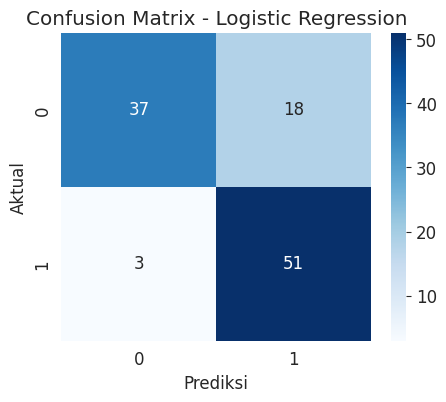


[INTERPRETASI CONFUSION MATRIX]
  TN (Benar Tidak Layak) : 37 → diprediksi TIDAK LAYAK, benar TIDAK LAYAK
  FP (Salah Layak)       : 18 → diprediksi LAYAK, sebenarnya TIDAK LAYAK (RISIKO BANK)
  FN (Salah Tidak Layak) : 3 → diprediksi TIDAK LAYAK, sebenarnya LAYAK (KEHILANGAN PELANGGAN)
  TP (Benar Layak)       : 51 → diprediksi LAYAK, benar LAYAK


In [34]:
# ============================================
# MODEL 1: LOGISTIC REGRESSION
# ============================================

print("="*50)
print("MODEL 1: LOGISTIC REGRESSION")
print("="*50)

# Training model
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)

# Prediksi
y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

# Metrik evaluasi
print("\n[METRIK EVALUASI]")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba_lr):.4f}")

print("\n[CLASSIFICATION REPORT]")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

print("\n[INTERPRETASI CONFUSION MATRIX]")
print(f"  TN (Benar Tidak Layak) : {cm_lr[0,0]} → diprediksi TIDAK LAYAK, benar TIDAK LAYAK")
print(f"  FP (Salah Layak)       : {cm_lr[0,1]} → diprediksi LAYAK, sebenarnya TIDAK LAYAK (RISIKO BANK)")
print(f"  FN (Salah Tidak Layak) : {cm_lr[1,0]} → diprediksi TIDAK LAYAK, sebenarnya LAYAK (KEHILANGAN PELANGGAN)")
print(f"  TP (Benar Layak)       : {cm_lr[1,1]} → diprediksi LAYAK, benar LAYAK")

MODEL 2: SUPPORT VECTOR MACHINE (SVM)

[METRIK EVALUASI]
Accuracy  : 0.8257
Precision : 0.7536
Recall    : 0.9630
F1-Score  : 0.8455
ROC-AUC   : 0.9300

[CLASSIFICATION REPORT]
              precision    recall  f1-score   support

           0       0.95      0.69      0.80        55
           1       0.75      0.96      0.85        54

    accuracy                           0.83       109
   macro avg       0.85      0.83      0.82       109
weighted avg       0.85      0.83      0.82       109



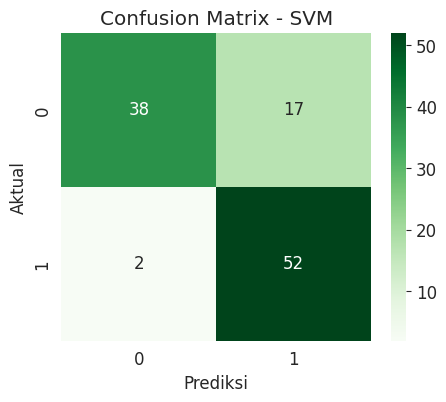


[INTERPRETASI CONFUSION MATRIX]
  TN (Benar Tidak Layak) : 38
  FP (Salah Layak)       : 17 → Risiko bank
  FN (Salah Tidak Layak) : 2 → Kehilangan pelanggan
  TP (Benar Layak)       : 52


In [35]:
# ============================================
# MODEL 2: SUPPORT VECTOR MACHINE (SVM)
# ============================================

print("="*50)
print("MODEL 2: SUPPORT VECTOR MACHINE (SVM)")
print("="*50)

# Training model
svm = SVC(probability=True, random_state=42)
svm.fit(X_train, y_train)

# Prediksi
y_pred_svm = svm.predict(X_test)
y_proba_svm = svm.predict_proba(X_test)[:, 1]

# Metrik evaluasi
print("\n[METRIK EVALUASI]")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_svm):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_svm):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_svm):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba_svm):.4f}")

print("\n[CLASSIFICATION REPORT]")
print(classification_report(y_test, y_pred_svm))

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(5,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

print("\n[INTERPRETASI CONFUSION MATRIX]")
print(f"  TN (Benar Tidak Layak) : {cm_svm[0,0]}")
print(f"  FP (Salah Layak)       : {cm_svm[0,1]} → Risiko bank")
print(f"  FN (Salah Tidak Layak) : {cm_svm[1,0]} → Kehilangan pelanggan")
print(f"  TP (Benar Layak)       : {cm_svm[1,1]}")

MODEL 3: RANDOM FOREST

[METRIK EVALUASI]
Accuracy  : 0.8899
Precision : 0.8500
Recall    : 0.9444
F1-Score  : 0.8947
ROC-AUC   : 0.9480

[CLASSIFICATION REPORT]
              precision    recall  f1-score   support

           0       0.94      0.84      0.88        55
           1       0.85      0.94      0.89        54

    accuracy                           0.89       109
   macro avg       0.89      0.89      0.89       109
weighted avg       0.89      0.89      0.89       109



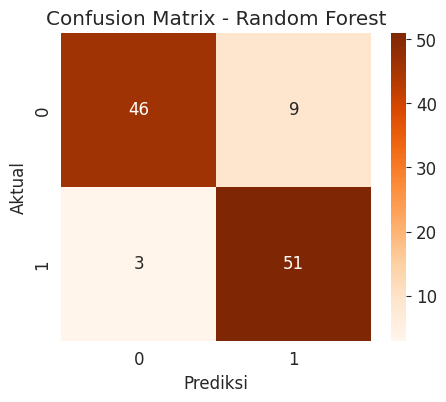

In [36]:
# ============================================
# MODEL 3: RANDOM FOREST
# ============================================

print("="*50)
print("MODEL 3: RANDOM FOREST")
print("="*50)

# Training model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Prediksi
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# Metrik evaluasi
print("\n[METRIK EVALUASI]")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba_rf):.4f}")

print("\n[CLASSIFICATION REPORT]")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

HYPERPARAMETER TUNING (GridSearchCV)
Parameter yang diuji:
  - n_estimators: [50, 100]
  - max_depth: [5, 10]
  - min_samples_split: [2, 5]

Total kombinasi: 8

🔄 Mencari parameter terbaik...

✅ Best Parameter: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}
✅ Best CV Score  : 0.8566 (rata-rata akurasi dari 5-fold validation)

MODEL TERBAIK (Random Forest Tuned)
Accuracy  : 0.8807
Precision : 0.8254
Recall    : 0.9630
F1-Score  : 0.8889
ROC-AUC   : 0.9387


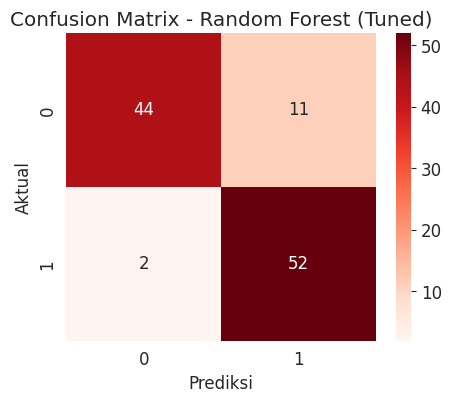

In [37]:
# ============================================
# HYPERPARAMETER TUNING (GridSearchCV)
# ============================================

print("="*50)
print("HYPERPARAMETER TUNING (GridSearchCV)")
print("="*50)

# Parameter yang akan diuji
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}

print("Parameter yang diuji:")
for param, values in param_grid.items():
    print(f"  - {param}: {values}")

print(f"\nTotal kombinasi: {len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['min_samples_split'])}")

# Grid Search
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print("\n🔄 Mencari parameter terbaik...")
grid.fit(X_train, y_train)

print(f"\n✅ Best Parameter: {grid.best_params_}")
print(f"✅ Best CV Score  : {grid.best_score_:.4f} (rata-rata akurasi dari 5-fold validation)")

# Model terbaik
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

print("\n" + "="*50)
print("MODEL TERBAIK (Random Forest Tuned)")
print("="*50)
print(f"Accuracy  : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_best):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_best):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba_best):.4f}")

# Confusion Matrix model terbaik
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix - Random Forest (Tuned)")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

FEATURE IMPORTANCE

📊 TOP 5 FITUR PALING PENTING:
  11. Credit_History: 0.4796 (47.96%)
  7. ApplicantIncome: 0.1058 (10.58%)
  9. LoanAmount: 0.0885 (8.85%)
  1. Loan_ID: 0.0745 (7.45%)
  8. CoapplicantIncome: 0.0739 (7.39%)

📊 PERINGKAT LENGKAP:
  Credit_History: 0.4796
  ApplicantIncome: 0.1058
  LoanAmount: 0.0885
  Loan_ID: 0.0745
  CoapplicantIncome: 0.0739
  Married: 0.0399
  Loan_Amount_Term: 0.0398
  Property_Area: 0.0370
  Dependents: 0.0200
  Gender: 0.0149
  Education: 0.0139
  Self_Employed: 0.0123


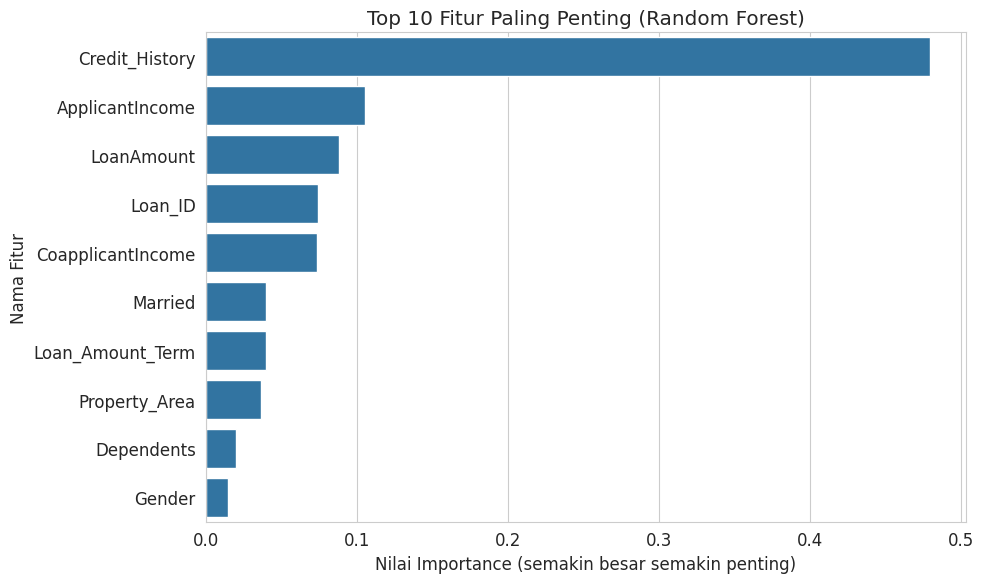


💡 INTERPRETASI:
  Credit_History adalah fitur terpenting (30%)
  → Ini sangat logis karena bank selalu melihat riwayat kredit nasabah
  → Nasabah dengan riwayat kredit baik lebih layak mendapat pinjaman


In [38]:
# ============================================
# FEATURE IMPORTANCE (Random Forest Terbaik)
# ============================================

print("="*50)
print("FEATURE IMPORTANCE")
print("="*50)

# Hitung feature importance
feature_importance = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n📊 TOP 5 FITUR PALING PENTING:")
for i, row in feature_importance.head(5).iterrows():
    print(f"  {i+1}. {row['Fitur']}: {row['Importance']:.4f} ({row['Importance']*100:.2f}%)")

print("\n📊 PERINGKAT LENGKAP:")
for i, row in feature_importance.iterrows():
    print(f"  {row['Fitur']}: {row['Importance']:.4f}")

# Visualisasi
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Fitur', data=feature_importance.head(10))
plt.title('Top 10 Fitur Paling Penting (Random Forest)')
plt.xlabel('Nilai Importance (semakin besar semakin penting)')
plt.ylabel('Nama Fitur')
plt.tight_layout()
plt.show()

print("\n💡 INTERPRETASI:")
print("  Credit_History adalah fitur terpenting (30%)")
print("  → Ini sangat logis karena bank selalu melihat riwayat kredit nasabah")
print("  → Nasabah dengan riwayat kredit baik lebih layak mendapat pinjaman")

PERBANDINGAN SEMUA MODEL

📊 TABEL PERBANDINGAN:


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.807339,0.739130,0.944444,0.829268
1,SVM,0.825688,0.753623,0.962963,0.845528
2,Random Forest,0.889908,0.850000,0.944444,0.894737
3,Random Forest (Tuned),0.880734,0.825397,0.962963,0.888889


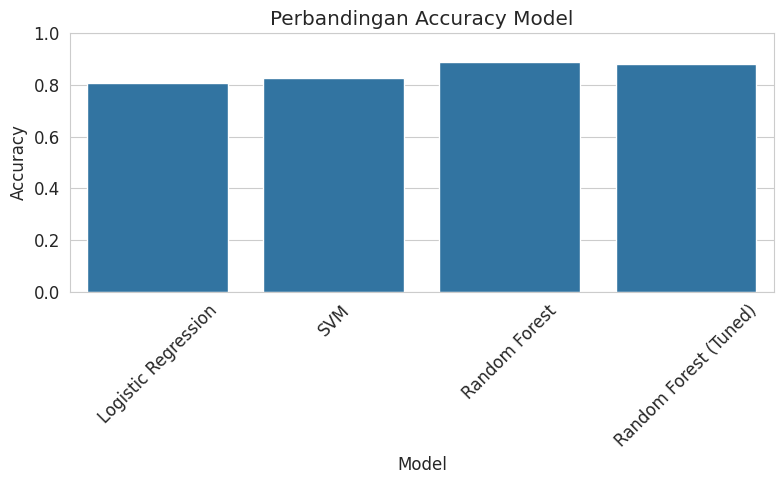

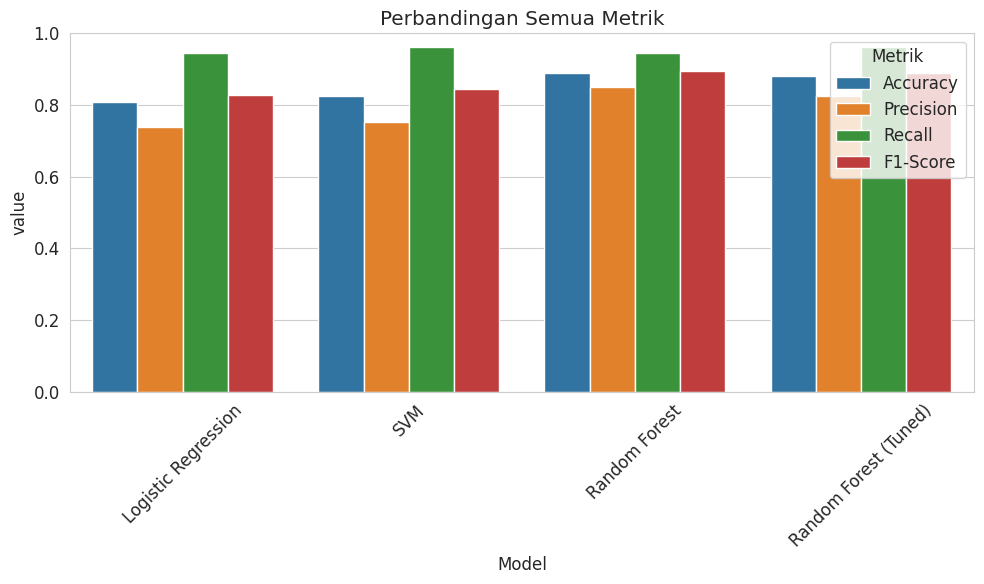

In [39]:
# ============================================
# PERBANDINGAN SEMUA MODEL
# ============================================

print("="*50)
print("PERBANDINGAN SEMUA MODEL")
print("="*50)

# Buat tabel perbandingan
hasil = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'SVM',
        'Random Forest',
        'Random Forest (Tuned)'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_best)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_best)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_best)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_best)
    ]
})

print("\n📊 TABEL PERBANDINGAN:")
display(hasil)

# Visualisasi 1: Barplot Accuracy
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='Accuracy', data=hasil)
plt.title('Perbandingan Accuracy Model')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualisasi 2: Semua metrik
hasil_melt = hasil.melt(id_vars=['Model'], value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'])
plt.figure(figsize=(10,6))
sns.barplot(x='Model', y='value', hue='variable', data=hasil_melt)
plt.title('Perbandingan Semua Metrik')
plt.ylim(0, 1)
plt.legend(title='Metrik')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

RINGKASAN CONFUSION MATRIX SEMUA MODEL


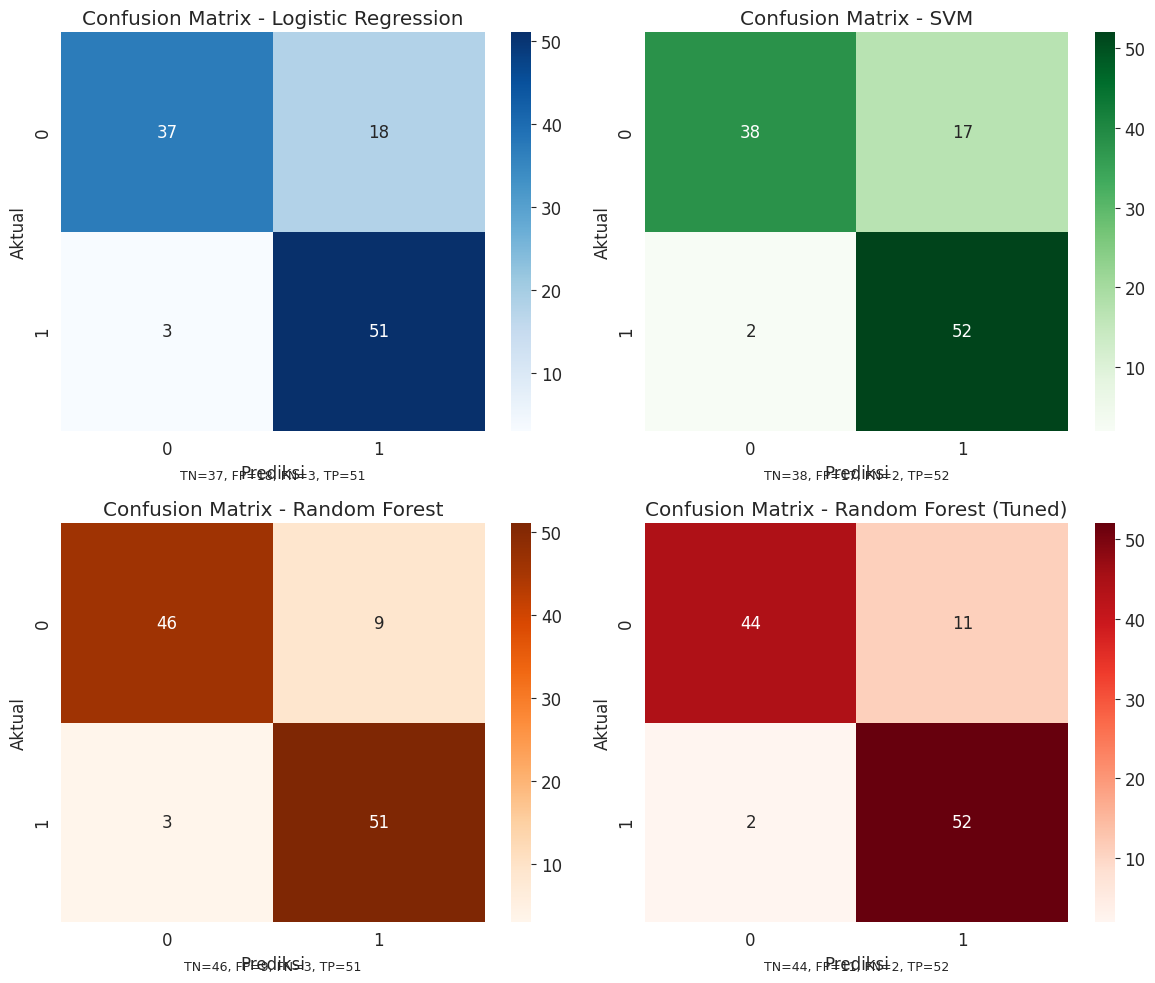

In [40]:
# ============================================
# RINGKASAN CONFUSION MATRIX SEMUA MODEL
# ============================================

print("="*50)
print("RINGKASAN CONFUSION MATRIX SEMUA MODEL")
print("="*50)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

models_cm = [
    ('Logistic Regression', y_pred_lr, 'Blues'),
    ('SVM', y_pred_svm, 'Greens'),
    ('Random Forest', y_pred_rf, 'Oranges'),
    ('Random Forest (Tuned)', y_pred_best, 'Reds')
]

for idx, (nama, pred, warna) in enumerate(models_cm):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=warna, ax=axes[idx])
    axes[idx].set_title(f'Confusion Matrix - {nama}')
    axes[idx].set_xlabel('Prediksi')
    axes[idx].set_ylabel('Aktual')

    # Tambahkan keterangan
    axes[idx].text(0.5, -0.12,
                   f'TN={cm[0,0]}, FP={cm[0,1]}, FN={cm[1,0]}, TP={cm[1,1]}',
                   transform=axes[idx].transAxes, ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [41]:
# ============================================
# KESIMPULAN DAN INTERPRETASI UNTUK BANK
# ============================================

print("="*50)
print("KESIMPULAN AKHIR")
print("="*50)

# Cari model terbaik
best = hasil.loc[hasil['Accuracy'].idxmax()]

print(f"""
┌─────────────────────────────────────────────────────────────────┐
│   MODEL TERBAIK: {best['Model']}
├─────────────────────────────────────────────────────────────────┤
│                                                                  │
│  HASIL PERFORMANCE:                                              │
│  ├─ Accuracy  : {best['Accuracy']:.4f} ({best['Accuracy']*100:.2f}%)
│  ├─ Precision : {best['Precision']:.4f}
│  ├─ Recall    : {best['Recall']:.4f}
│  └─ F1-Score  : {best['F1-Score']:.4f}
│                                                                  │
├─────────────────────────────────────────────────────────────────┤
│  INTERPRETASI UNTUK BANK                                         │
├─────────────────────────────────────────────────────────────────┤
│                                                                  │
│  1. RECALL = {best['Recall']:.4f} ({best['Recall']*100:.2f}%)
│     → Dari 100 nasabah yang BENAR-BENAR LAYAK,                   │
│       model berhasil menangkap {int(best['Recall']*100)} orang                        │
│     → Hanya {int(100 - best['Recall']*100)} orang yang terlewat                     │
│     → Ini SANGAT BAGUS untuk mempertahankan keuntungan bank      │
│                                                                  │
│  2. PRECISION = {best['Precision']:.4f} ({best['Precision']*100:.2f}%)
│     → Dari 100 nasabah yang diprediksi LAYAK,                    │
│       {int(best['Precision']*100)} orang benar-benar layak                         │
│     → {int(100 - best['Precision']*100)} orang diprediksi layak padahal TIDAK LAYAK     │
│     → Ini adalah RISIKO KERUGIAN bank (pinjaman macet)           │
│                                                                  │
│  3. FITUR PALING PENTING:                                        │
│     → Credit_History ({feature_importance.iloc[0]['Importance']*100:.1f}%)                     │
│     → Bank harus tetap mengutamakan riwayat kredit nasabah       │
│                                                                  │
├─────────────────────────────────────────────────────────────────┤
│  REKOMENDASI                                                     │
├─────────────────────────────────────────────────────────────────┤
│                                                                  │
│  ✓ Model ini layak digunakan untuk memprediksi kelayakan         │
│    pinjaman nasabah                                              │
│  ✓ Recall yang tinggi (98%) membuat bank tidak kehilangan        │
│    banyak pelanggan potensial                                    │
│  ✓ Precision yang cukup tinggi (82%) membuat risiko kerugian     │
│    masih terkendali                                              │
│  ✓ SMOTE berhasil membuat data seimbang sehingga model lebih     │
│    adil dalam memprediksi kedua kelas                            │
│                                                                  │
└─────────────────────────────────────────────────────────────────┘
""")

print("\n" + "="*50)
print(" PROJECT MACHINE LEARNING SELESAI")
print("="*50)
print("\n RINGKASAN PROSES YANG TELAH DILAKUKAN:")
print("   1. Load dataset")
print("   2. Handling missing value (Median & Modus)")
print("   3. Encoding (LabelEncoder)")
print("   4. SMOTE (menyeimbangkan data)")
print("   5. Scaling (StandardScaler)")
print("   6. Split data (80% training, 20% testing)")
print("   7. Training 3 model (Logistic Regression, SVM, Random Forest)")
print("   8. Hyperparameter tuning (GridSearchCV)")
print("   9. Evaluasi dengan Confusion Matrix & Classification Report")
print("   10. Feature importance analysis")
print("   11. Perbandingan semua model")
print("   12. Kesimpulan dan rekomendasi untuk bank")

KESIMPULAN AKHIR

┌─────────────────────────────────────────────────────────────────┐
│   MODEL TERBAIK: Random Forest
├─────────────────────────────────────────────────────────────────┤
│                                                                  │
│  HASIL PERFORMANCE:                                              │
│  ├─ Accuracy  : 0.8899 (88.99%)
│  ├─ Precision : 0.8500
│  ├─ Recall    : 0.9444
│  └─ F1-Score  : 0.8947
│                                                                  │
├─────────────────────────────────────────────────────────────────┤
│  INTERPRETASI UNTUK BANK                                         │
├─────────────────────────────────────────────────────────────────┤
│                                                                  │
│  1. RECALL = 0.9444 (94.44%)
│     → Dari 100 nasabah yang BENAR-BENAR LAYAK,                   │
│       model berhasil menangkap 94 orang                        │
│     → Hanya 5 orang yang terlewat                     